In [7]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib

# import data
path = 'fraud_applications.csv'
df=pd.read_csv(path)
df.head()

,application_id,name,email,submission_time,phone_number,marks
0,1,User1,user1@mail.com,52,6950318585,98
1,2,User2,user2@mail.com,93,1068574553,98
2,3,User3,user3@mail.com,15,1991681409,61
3,4,User4,user4@mail.com,72,4578544903,88
4,5,User5,user5@mail.com,61,6974559824,51


In [14]:
# Step 2: Basic preprocessing

# 1. Check structure
print("Shape of data:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Shape of data: (50, 6)

Column names: ['application_id', 'name', 'email', 'submission_time', 'phone_number', 'marks']

Data types:
application_id      int64
name               object
email              object
submission_time     int64
phone_number       object
marks               int64
dtype: object


In [9]:
# 2. Check for missing values
print(df.isnull().sum())

application_id     0
name               0
email              0
submission_time    0
phone_number       0
marks              0
dtype: int64


In [17]:
# check duplicates
print(df.duplicated().sum())

0


In [19]:
from sklearn.cluster import KMeans
import numpy as np

# Step 4: K-Means Clustering
X_values = df[['submission_time', 'marks']].values

# Create KMeans model (2 clusters work well for simple anomaly detection)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_values)

df['cluster'] = clusters

# Calculate distance of each point to its cluster center
centroids = kmeans.cluster_centers_
distances = np.linalg.norm(X_values - centroids[clusters], axis=1)
df['distance_from_center'] = distances

# Compute threshold: mean + 2*std
threshold = df['distance_from_center'].mean() + 2 * df['distance_from_center'].std()

# Flag anomalies
df['anomaly_kmeans'] = np.where(df['distance_from_center'] > threshold, 'Suspicious', 'Normal')

# Show result summary
print("K-Means suspicious counts:")
print(df['anomaly_kmeans'].value_counts())

# Display suspicious records
df[df['anomaly_kmeans'] == 'Suspicious']


C:\Users\mehar\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\mehar\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\mehar\AppData\Local\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mehar\AppData\Local\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_

K-Means suspicious counts:
anomaly_kmeans
Normal        48
Suspicious     2
Name: count, dtype: int64


C:\Users\mehar\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,application_id,name,email,submission_time,phone_number,marks,anomaly_iso,cluster,distance_from_center,anomaly_kmeans
20,21,User21,user21@mail.com,64,3602578298,10,Suspicious,0,62.004588,Suspicious
30,31,User31,user31@mail.com,59,4052273870,15,Suspicious,0,57.595447,Suspicious


In [21]:
# Step 5: Rule-based fraud detection

# 1. Check for duplicate emails or phone numbers
duplicate_emails = df[df.duplicated('email', keep=False)]
duplicate_phones = df[df.duplicated('phone_number', keep=False)]

# 2. Check for very rapid submissions 
rapid_submissions = df[df['submission_time'] < 5]

# 3. Check for extremely low marks 
low_marks = df[df['marks'] < 20]

print( duplicate_emails)
print( duplicate_phones)
print(rapid_submissions)
print( low_marks)

# Add a final column summarizing if any rule is triggered
df['rule_based_flag'] = 'Normal'
df.loc[df['email'].isin(duplicate_emails['email']), 'rule_based_flag'] = 'Suspicious'
df.loc[df['phone_number'].isin(duplicate_phones['phone_number']), 'rule_based_flag'] = 'Suspicious'
df.loc[df['submission_time'] < 5, 'rule_based_flag'] = 'Suspicious'
df.loc[df['marks'] < 20, 'rule_based_flag'] = 'Suspicious'

# Summary
print("\nRule-based suspicious counts:")
print(df['rule_based_flag'].value_counts())

# Display suspicious records
df[df['rule_based_flag'] == 'Suspicious']


   application_id   name           email  submission_time phone_number  marks  \
1               2  User2  user2@mail.com               93   1068574553     98   
5               6  User6  user2@mail.com               21   7120997885     52   

  anomaly_iso  cluster  distance_from_center anomaly_kmeans rule_based_flag  
1  Suspicious        0             36.073567         Normal      Suspicious  
5      Normal        1             14.454411         Normal      Suspicious  
    application_id    name            email  submission_time phone_number  \
2                3   User3   user3@mail.com               15   1991681409   
25              26  User26  user26@mail.com               58   1991681409   

    marks anomaly_iso  cluster  distance_from_center anomaly_kmeans  \
2      61      Normal        1              6.158734         Normal   
25     81      Normal        0             13.641929         Normal   

   rule_based_flag  
2       Suspicious  
25      Suspicious  
    applicati

,application_id,name,email,submission_time,phone_number,marks,anomaly_iso,cluster,distance_from_center,anomaly_kmeans,rule_based_flag
1,2,User2,user2@mail.com,93,1068574553,98,Suspicious,0,36.073567,Normal,Suspicious
2,3,User3,user3@mail.com,15,1991681409,61,Normal,1,6.158734,Normal,Suspicious
5,6,User6,user2@mail.com,21,7120997885,52,Normal,1,14.454411,Normal,Suspicious
15,16,User16,user16@mail.com,2,3520077079,86,Suspicious,1,25.646247,Normal,Suspicious
19,20,User20,user20@mail.com,2,4055190407,68,Normal,1,16.399085,Normal,Suspicious
20,21,User21,user21@mail.com,64,3602578298,10,Suspicious,0,62.004588,Suspicious,Suspicious
25,26,User26,user26@mail.com,58,1991681409,81,Normal,0,13.641929,Normal,Suspicious
30,31,User31,user31@mail.com,59,4052273870,15,Suspicious,0,57.595447,Suspicious,Suspicious
43,44,User44,user44@mail.com,3,3781807898,52,Normal,1,20.874147,Normal,Suspicious


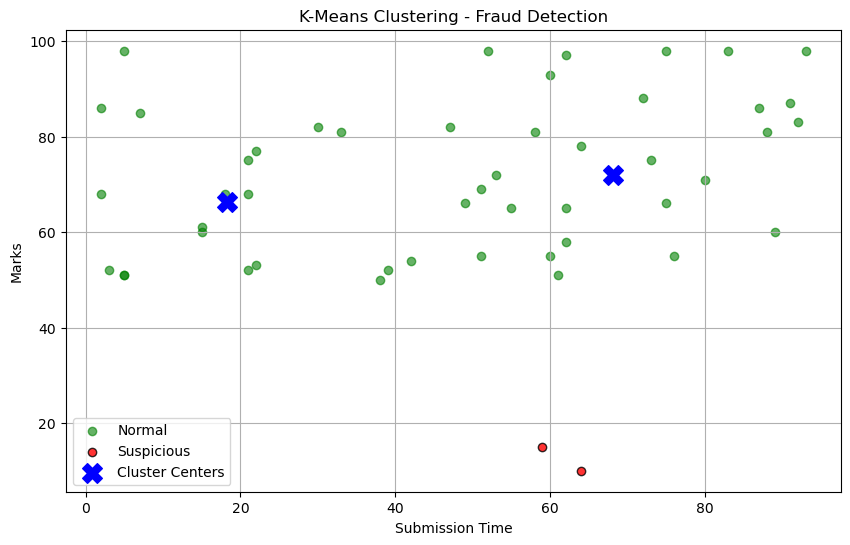

In [23]:
import matplotlib.pyplot as plt

# Step 7: Visualization
plt.figure(figsize=(10,6))

# Plot normal points
normal_points = df[df['anomaly_kmeans'] == 'Normal']
plt.scatter(normal_points['submission_time'], 
            normal_points['marks'], 
            c='green', label='Normal', alpha=0.6)

# Plot suspicious points
suspicious_points = df[df['anomaly_kmeans'] == 'Suspicious']
plt.scatter(suspicious_points['submission_time'], 
            suspicious_points['marks'], 
            c='red', label='Suspicious', alpha=0.8, edgecolors='black')

# Plot cluster centers
plt.scatter(kmeans.cluster_centers_[:,0], 
            kmeans.cluster_centers_[:,1], 
            c='blue', marker='X', s=200, label='Cluster Centers')

plt.title('K-Means Clustering - Fraud Detection')
plt.xlabel('Submission Time')
plt.ylabel('Marks')
plt.legend()
plt.grid(True)
plt.show()


In [24]:
Interpretation:

We applied K-Means clustering on the internship application data using submission_time and marks as the main features.

The green points on the graph represent normal applications that have typical marks and submission patterns.

The blue X marks represent the cluster centers, i.e., the average behavior of normal applicants.

The 2 red points represent suspicious applications. These are far away from the cluster centers, which means their behavior is very different from the majority.

These 2 suspicious applications have very low marks and unusual submission times compared to others.
Such outliers may indicate:

Fake entries,
Data entry mistakes, or
Applicants trying to bypass normal submission patterns.

SyntaxError: invalid syntax (3068910658.py, line 1)